### Classification using Deep neural network (Any One from the following
- Multiclass classification using Deep Neural Networks: Example: Use the OCR letter
recognition dataset https://archive.ics.uci.edu/ml/datasets/letter+recognition

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.metrics import confusion_matrix,classification_report
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
     



In [73]:
columns=['letters','x1','y1','x2','y2','x3','y3','x4','y4','x5','y5','x6','y6','x7','y7','x8','y8']

In [74]:
data = pd.read_csv('letter-recognition.csv',names=columns,header=None)
data.head()

,letters,x1,y1,x2,y2,x3,y3,x4,y4,x5,y5,x6,y6,x7,y7,x8,y8
0,T,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,I,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,D,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,N,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,G,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10


In [75]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 17 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   letters  20000 non-null  str  
 1   x1       20000 non-null  int64
 2   y1       20000 non-null  int64
 3   x2       20000 non-null  int64
 4   y2       20000 non-null  int64
 5   x3       20000 non-null  int64
 6   y3       20000 non-null  int64
 7   x4       20000 non-null  int64
 8   y4       20000 non-null  int64
 9   x5       20000 non-null  int64
 10  y5       20000 non-null  int64
 11  x6       20000 non-null  int64
 12  y6       20000 non-null  int64
 13  x7       20000 non-null  int64
 14  y7       20000 non-null  int64
 15  x8       20000 non-null  int64
 16  y8       20000 non-null  int64
dtypes: int64(16), str(1)
memory usage: 2.6 MB


In [76]:
data.isnull().sum()

letters    0
x1         0
y1         0
x2         0
y2         0
x3         0
y3         0
x4         0
y4         0
x5         0
y5         0
x6         0
y6         0
x7         0
y7         0
x8         0
y8         0
dtype: int64

In [77]:
data["letters"].value_counts()

letters
U    813
D    805
P    803
T    796
M    792
A    789
X    787
Y    786
N    783
Q    783
F    775
G    773
E    768
B    766
V    764
L    761
R    758
I    755
O    753
W    752
S    748
J    747
K    739
C    736
H    734
Z    734
Name: count, dtype: int64

In [78]:
#Encoding the characters
encoder=LabelEncoder()

#Train_test split
x=data.drop('letters',axis=1)
y=data['letters']
y_encoded=encoder.fit_transform(y)
y_catego=to_categorical(y_encoded)
x_train,x_test,y_train,y_test= train_test_split(x,y_catego,test_size=0.2,random_state=42)
     

#Scaling the date
scaler=StandardScaler()
x_train_scale= scaler.fit_transform(x_train)
x_test_scale=scaler.transform(x_test)
     

#Model Build
model = Sequential([
                    Dense(128,activation='relu', input_shape = (x_train.shape[1],)),
                    Dense(64,activation='relu'),
                    Dense(32,activation='relu'),
                    Dense(26,activation='softmax')])

#Model Compile
model.compile('adam',loss='categorical_crossentropy',metrics=['accuracy'])
model.summary()
     


/home/naveed-malik/myenv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 26)             │           858 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,370 (52.23 KB)

 Trainable params: 13,370 (52.23 KB)

 Non-trainable params: 0 (0.00 B)

In [79]:
history= model.fit(x_train_scale,y_train,epochs=50,validation_split=0.2,verbose=1)

Epoch 1/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5345 - loss: 1.6220 - val_accuracy: 0.7334 - val_loss: 0.9071
Epoch 2/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7769 - loss: 0.7319 - val_accuracy: 0.8094 - val_loss: 0.6388
Epoch 3/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8369 - loss: 0.5470 - val_accuracy: 0.8406 - val_loss: 0.5140
Epoch 4/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8669 - loss: 0.4444 - val_accuracy: 0.8747 - val_loss: 0.4308
Epoch 5/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8875 - loss: 0.3705 - val_accuracy: 0.8828 - val_loss: 0.3768
Epoch 6/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9030 - loss: 0.3154 - val_accuracy: 0.8966 - val_loss: 0.3367
Epoch 7/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9146 - loss: 0.2773 - val_accuracy: 0.9072 - val_loss: 0.3130
Epoch 8/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9227 - loss: 0.2474 - val_accuracy: 0.

In [80]:
#Predictions
y_pred=model.predict(x_test_scale)

pred_indices= np.argmax(y_pred,axis=1)
actual_indices=np.argmax(y_test,axis=1)

pred_label=encoder.inverse_transform(pred_indices)
actual_label=encoder.inverse_transform(actual_indices)

print("Prediction Vs Accuracy")
for i in range(10):
    print(f"Actual: {actual_label[i]}, Predicted: {pred_label[i]}")

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 744us/step
Prediction Vs Accuracy
Actual: T, Predicted: E
Actual: L, Predicted: L
Actual: A, Predicted: A
Actual: E, Predicted: E
Actual: Q, Predicted: Q
Actual: E, Predicted: E
Actual: O, Predicted: O
Actual: Q, Predicted: Q
Actual: G, Predicted: G
Actual: O, Predicted: O


In [81]:
#Model Evaluation
loss,accuracy= model.evaluate(x_test_scale,y_test)
print("Model loss: ",loss*100)
print("Model accuracy: ",accuracy*100)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9592 - loss: 0.1614  
Model loss:  16.14125370979309
Model accuracy:  95.92499732971191


In [82]:
#Classification report
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)   # only if one-hot encoded

print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       149
           1       0.93      0.99      0.96       153
           2       0.96      0.93      0.94       137
           3       0.93      0.97      0.95       156
           4       0.91      0.96      0.93       141
           5       0.96      0.95      0.95       140
           6       0.92      0.97      0.95       160
           7       0.96      0.89      0.92       144
           8       0.95      0.97      0.96       146
           9       0.99      0.95      0.97       149
          10       0.93      0.93      0.93       130
          11       0.98      0.94      0.96       155
          12       0.98      1.00      0.99       168
          13       0.99      0.95      0.97       151
          14       0.95      0.97      0.96       145
          15       0.95      0.98      0.97       173
          16       1.00      0.95      0.98       166
          17       0.93    

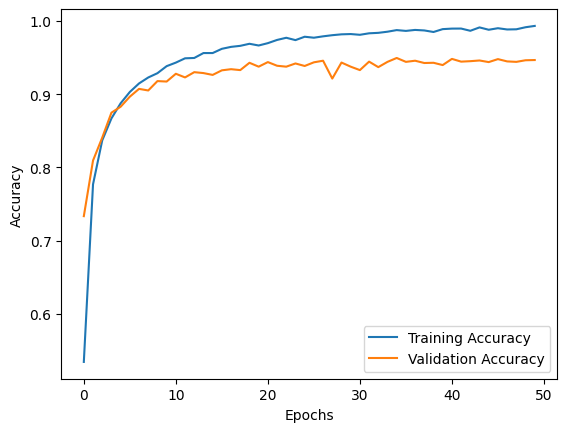

In [83]:
#Accuracy vs Epochs
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show();
     


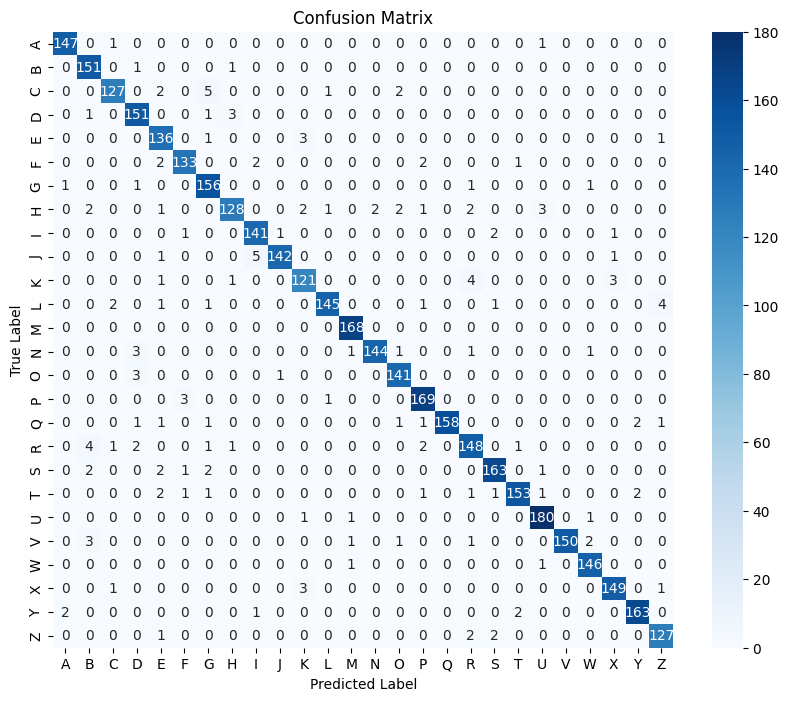

In [84]:
#Confusion matrix
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=encoder.classes_, 
            yticklabels=encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()